In [1]:
import pandas as pd

df = pd.read_csv("insurance.csv")

df.head()

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


In [2]:
import piplite
await piplite.install('seaborn')

ModuleNotFoundError: No module named 'piplite'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv('insurance.csv', header=None)
print(df.head(10))

    0  1       2  3  4  5            6
0  19  1  27.900  0  1  3  16884.92400
1  18  2  33.770  1  0  4   1725.55230
2  28  2  33.000  3  0  4   4449.46200
3  33  2  22.705  0  0  1  21984.47061
4  32  2  28.880  0  0  1   3866.85520
5  31  1  25.740  0  ?  4   3756.62160
6  46  1  33.440  1  0  4   8240.58960
7  37  1  27.740  3  0  1   7281.50560
8  37  2  29.830  2  0  2   6406.41070
9  60  1  25.840  0  0  1  28923.13692


In [6]:
headers = ['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges']
df.columns = headers

In [7]:
print(df.head(10))

  age  gender     bmi  children smoker  region      charges
0  19       1  27.900         0      1       3  16884.92400
1  18       2  33.770         1      0       4   1725.55230
2  28       2  33.000         3      0       4   4449.46200
3  33       2  22.705         0      0       1  21984.47061
4  32       2  28.880         0      0       1   3866.85520
5  31       1  25.740         0      ?       4   3756.62160
6  46       1  33.440         1      0       4   8240.58960
7  37       1  27.740         3      0       1   7281.50560
8  37       2  29.830         2      0       2   6406.41070
9  60       1  25.840         0      0       1  28923.13692


In [8]:
df.replace('?', np.nan, inplace=True)

,age,gender,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
2767,47,1,45.320,1,0,4,8569.86180
2768,21,1,34.600,0,0,3,2020.17700
2769,19,2,26.030,1,1,1,16450.89470
2770,23,2,18.715,0,0,1,21595.38229


In [9]:
# Data wrangling
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2768 non-null   str    
 1   gender    2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2765 non-null   str    
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB
None


In [11]:
# smoker is a categorical attribute, replace with most frequent entry
is_smoker = df['smoker'].value_counts().idxmax()
df["smoker"] = df["smoker"].replace(np.nan, is_smoker)

# age is a continuous variable, replace with mean age
mean_age = df['age'].astype('float').mean(axis=0)
df["age"] = df["age"].replace(np.nan, mean_age)

# Update data types
df["age"] = df["age"].astype("int")

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   gender    2772 non-null   int64  
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   int64  
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(4), str(1)
memory usage: 151.7 KB
None


In [12]:
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())

   age  gender     bmi  children smoker  region   charges
0   19       1  27.900         0      1       3  16884.92
1   18       2  33.770         1      0       4   1725.55
2   28       2  33.000         3      0       4   4449.46
3   33       2  22.705         0      0       1  21984.47
4   32       2  28.880         0      0       1   3866.86


(0.0, 66902.85800000001)

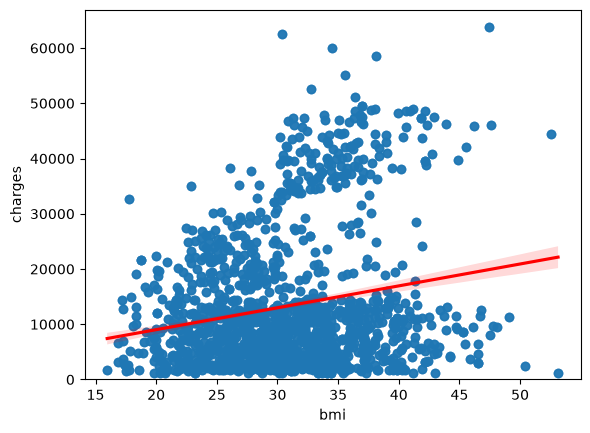

In [13]:
# Exploratory Data Analysis (EDA)
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

<Axes: xlabel='smoker', ylabel='charges'>

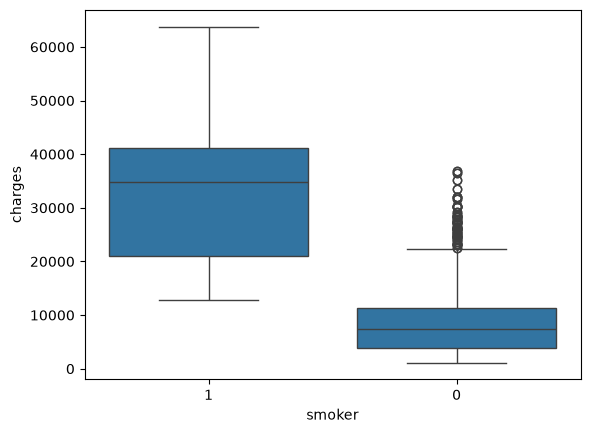

In [14]:
sns.boxplot(x="smoker", y="charges", data=df)

In [15]:
print(df.corr())

               age    gender       bmi  children    smoker    region   charges
age       1.000000 -0.026046  0.113048  0.037574 -0.023286 -0.007167  0.298624
gender   -0.026046  1.000000  0.042924  0.016020  0.082326  0.022213  0.062837
bmi       0.113048  0.042924  1.000000 -0.001492  0.011489  0.271119  0.199846
children  0.037574  0.016020 -0.001492  1.000000  0.006362 -0.025717  0.066442
smoker   -0.023286  0.082326  0.011489  0.006362  1.000000  0.054077  0.788783
region   -0.007167  0.022213  0.271119 -0.025717  0.054077  1.000000  0.054058
charges   0.298624  0.062837  0.199846  0.066442  0.788783  0.054058  1.000000


In [16]:
#  Model Development
X = df[['smoker']]
Y = df['charges']
lm = LinearRegression()
lm.fit(X,Y)
print(lm.score(X, Y))

0.6221791733924185


In [18]:
# deginition of Y and lm remain same as used in last cell.
Z = df[["age", "gender", "bmi", "children", "smoker", "region"]]
lm.fit(Z,Y)
print(lm.score(Z, Y))

0.7504083820289634


In [19]:
# Y and Z use the same values as defined in previous cells 
Input=[('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe=Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z,Y)
ypipe=pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8452576213500093


In [20]:
# Model Refinement
# Z and Y hold same values as in previous cells
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state=1)

In [21]:
# x_train, x_test, y_train, y_test hold same values as in previous cells
RidgeModel=Ridge(alpha=0.1)
RidgeModel.fit(x_train, y_train)
yhat = RidgeModel.predict(x_test)
print(r2_score(y_test,yhat))

0.6760807731582401


In [22]:
# x_train, x_test, y_train, y_test hold same values as in previous cells
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
RidgeModel.fit(x_train_pr, y_train)
y_hat = RidgeModel.predict(x_test_pr)
print(r2_score(y_test,y_hat))

0.7835631107608165
